# **1. 드라이브 연결**

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


# **2. 모델 및 함수 정의**

In [2]:
import os
import pandas as pd
import torch
import torch.nn as nn
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# GPU/CPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")


# CasualConv1d layer
# 과거-현재 데이터만 보고 특징을 추출함
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=self.padding, dilation=dilation)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [
                CausalConv1d(in_channels, out_channels, kernel_size, dilation=dilation_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class TRACE_GPT(nn.Module):
    def __init__(self, num_sensors, seq_len, d_model=128, n_head=8, num_layers=6, resolution=100, dropout=0.1):
        super(TRACE_GPT, self).__init__()
        self.num_sensors = num_sensors
        self.seq_len = seq_len
        self.resolution = resolution
        self.d_model = d_model

        # TCN 4층 (Receptive Field 확보)
        tcn_channels = [d_model] * 4

        self.tcn = TemporalConvNet(
            num_inputs=num_sensors + 1, # +1 for Time Index
            num_channels=tcn_channels,
            kernel_size=3,
            dropout=dropout
        )

        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head, batch_first=True, dropout=dropout),
            num_layers=num_layers
        )

        self.output_head = nn.Linear(d_model, num_sensors * resolution)

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x):
        batch_size, curr_seq_len, _ = x.size()

        # Positional Embedding
        steps = torch.arange(curr_seq_len, device=x.device, dtype=torch.float32)
        time_idx = (steps / self.seq_len).unsqueeze(0).unsqueeze(2)
        time_idx = time_idx.expand(batch_size, -1, -1)

        x_emb = torch.cat([x, time_idx], dim=2)

        x_tcn = x_emb.permute(0, 2, 1)
        x_tcn = self.tcn(x_tcn)
        x_tcn = x_tcn.permute(0, 2, 1)

        tgt_mask = self._generate_square_subsequent_mask(curr_seq_len).to(x.device)
        output = self.transformer_encoder(x_tcn, mask=tgt_mask, is_causal=True)

        logits = self.output_head(output)
        logits = logits.view(batch_size, curr_seq_len, self.num_sensors, self.resolution)

        return logits


def preprocess_and_window(df_wafer, sensor_cols, seq_len, scaler):
    """실시간 Raw 데이터를 스케일링하고 슬라이딩 윈도우 텐서로 변환"""
    data_values = df_wafer[sensor_cols].values
    data_scaled = scaler.transform(data_values) # 저장된 scaler로 변환

    sequences = []
    if len(data_scaled) < seq_len:
        print(f"⚠️ 데이터 길이가 시퀀스 길이({seq_len})보다 짧아 처리할 수 없습니다.")
        return None

    for i in range(len(data_scaled) - seq_len + 1):
        sequences.append(data_scaled[i : i + seq_len])

    return torch.FloatTensor(np.array(sequences)) # [Window_Num, 32, 19]


# 변환 함수
# 0~1 사이의 실수 데이터를 0~99 사이의 정수 데이터로 변환
def quantize_data(x, resolution=100):
    x_idx = (x * (resolution - 1)).long()
    x_idx = torch.clamp(x_idx, 0, resolution - 1)
    return x_idx


# 학습 함수
def train_trace_gpt(model, train_loader, optimizer, epoch, device, resolution=100):
    model.train()
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # Input(0~T-1) -> Target(1~T): 데이터 분할
        input_seq = data[:, :-1, :]
        target_seq = data[:, 1:, :]
        target_idx = quantize_data(target_seq, resolution)

        output_logits = model(input_seq)

        # loss 계산 (모델의 예측과 실제 정답 간의 차이)
        loss = criterion(
            output_logits.reshape(-1, resolution),
            target_idx.reshape(-1)
        )
        # 가중치 업데이트
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 10 == 0: # 10 epoch마다 로그 출력
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def trace_calculate_window_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion = nn.CrossEntropyLoss(reduction='none')   # loss 계산

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq = data[:, :-1, :]   # 입력 데이터
            target_seq = data[:, 1:, :]   # 정답 데이터
            target_idx = quantize_data(target_seq, resolution)    # 정답 데이터를 0~99로 변환

            output_logits = model(input_seq)    # 모델이 예측한 확률값

            loss_element = criterion(
                output_logits.reshape(-1, resolution),
                target_idx.reshape(-1)
            )
            loss_element = loss_element.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])

            # Window별 평균 Loss
            score_window = loss_element.mean(dim=[1, 2])
            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)



def trace_calculate_rca_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion_none = nn.CrossEntropyLoss(reduction='none')
    loader = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq, target_seq = data[:, :-1, :], data[:, 1:, :]
            target_idx = quantize_data(target_seq, resolution)
            logits = model(input_seq)
            loss_elem = criterion_none(logits.reshape(-1, resolution), target_idx.reshape(-1))
            loss_elem = loss_elem.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])
            all_scores.append(loss_elem.mean(dim=1).cpu().numpy()) # [시간] 축만 평균, [센서] 차원 보존
    return np.concatenate(all_scores, axis=0)

def analyze_single_wafer(model, wafer_tensor, wafer_id, threshold, sensor_cols, device, resolution=100, is_fault=False):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # =================================================================
    # 정상/불량 상관없이 모든 웨이퍼에 대해 RCA(변수별 점수) 분석 수행
    # =================================================================
    rca_scores = trace_calculate_rca_scores(model, wafer_tensor, device, batch_size=32, resolution=resolution)
    wafer_sensor_scores = rca_scores.mean(axis=0)

    # 내림차순 정렬
    sorted_indices = np.argsort(wafer_sensor_scores)[::-1]
    sorted_sensors = [sensor_cols[i] for i in sorted_indices]
    sorted_scores = wafer_sensor_scores[sorted_indices]

    status = "Fault" if is_fault else "Normal"

    # 하나의 엑셀로 합치기 위해 웨이퍼 ID와 상태를 포함한 DataFrame 생성
    rca_df = pd.DataFrame({
        'Wafer_ID': wafer_id,
        'Status': status,
        'Rank': range(1, len(sorted_sensors) + 1),
        'Sensor': sorted_sensors,
        'Anomaly_Score': sorted_scores
    })

    # =================================================================
    # 불량(Fault)일 경우에만 상세 시각화(그래프) 출력
    # =================================================================
    if is_fault:
        print(f"\n" + "="*55)
        print(f" 🏭 Wafer Analysis Report: [ {wafer_id} ]")
        print("="*55)
        print(f"▶ 판정: 🚨 불량 (Fault) 감지")
        print("-" * 55)
        print("[Root Cause Analysis - Top 5 Sensors]")

        top_k = 5
        top_sensors = sorted_sensors[:top_k]
        top_scores = sorted_scores[:top_k]

        plt.figure(figsize=(8, 4))
        sns.barplot(x=top_scores, y=top_sensors, palette='Reds_r')
        plt.title(f"RCA - Top {top_k} Anomalous Sensors ({wafer_id})", fontweight='bold')
        plt.xlabel("Anomaly Score (Loss)")
        plt.ylabel("Sensors")
        plt.tight_layout()
        plt.show()

        for i, (sensor, score) in enumerate(zip(top_sensors, top_scores)):
            print(f"  {i+1}위. {sensor}: {score:.4f}")

    return rca_df

✅ Using device: cpu


# **3. 예측 실행**

 거대 원본 데이터 로드 중 (1회만 수행됩니다): /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx
 원본 데이터 로드 완료!


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [l29] 실험군 전체 테스트셋 분석 시작
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ 모델 로드 성공! (Threshold: 3.1737)
▶ 타겟 데이터: 정상 14개 | 불량 9개 (총 분석 대상: 23개)


 🏭 Wafer Analysis Report: [ l2915.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


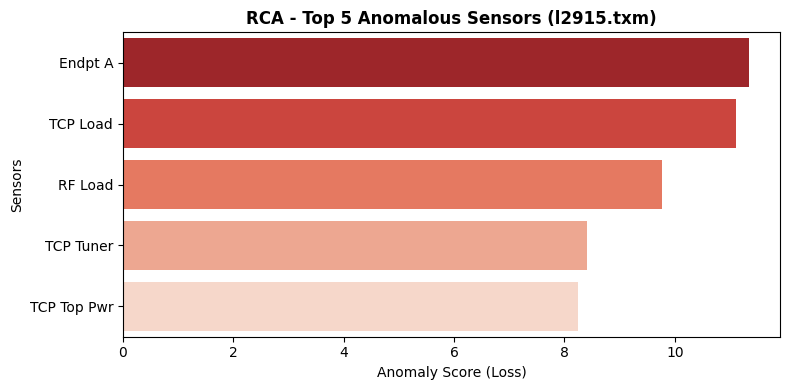

  1위. Endpt A: 11.3401
  2위. TCP Load: 11.1107
  3위. RF Load: 9.7745
  4위. TCP Tuner: 8.4070
  5위. TCP Top Pwr: 8.2511

 🏭 Wafer Analysis Report: [ l2916.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


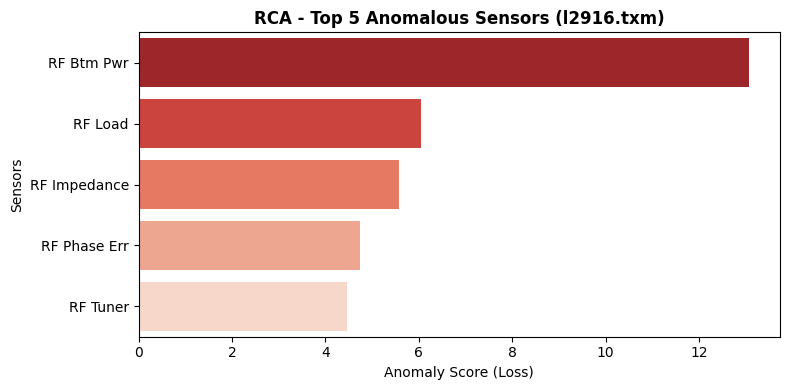

  1위. RF Btm Pwr: 13.0820
  2위. RF Load: 6.0540
  3위. RF Impedance: 5.5673
  4위. RF Phase Err: 4.7449
  5위. RF Tuner: 4.4559

 🏭 Wafer Analysis Report: [ l2917.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


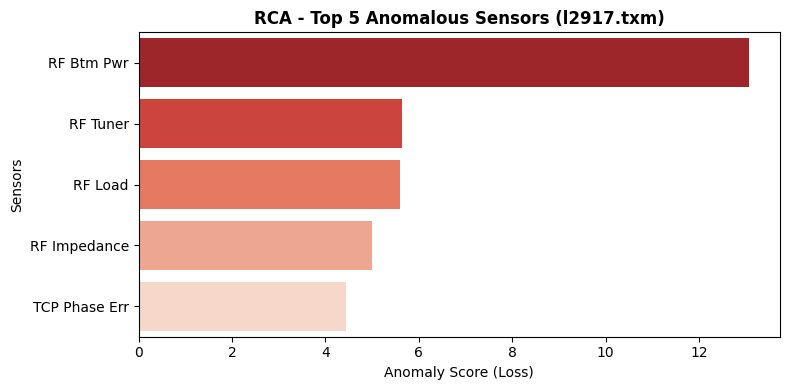

  1위. RF Btm Pwr: 13.0785
  2위. RF Tuner: 5.6474
  3위. RF Load: 5.5930
  4위. RF Impedance: 5.0043
  5위. TCP Phase Err: 4.4331

 🏭 Wafer Analysis Report: [ l2918.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


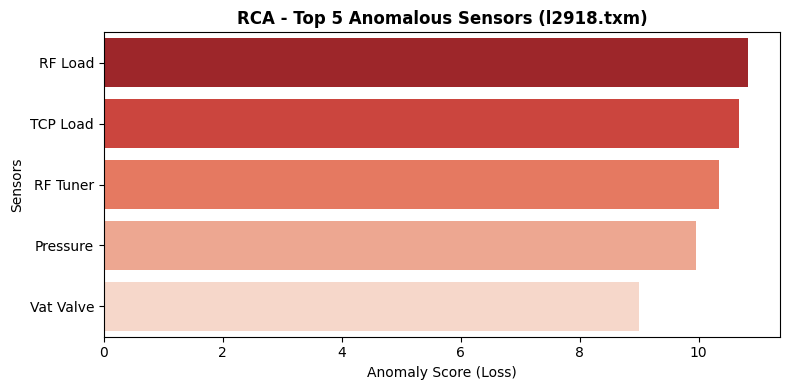

  1위. RF Load: 10.8271
  2위. TCP Load: 10.6725
  3위. RF Tuner: 10.3463
  4위. Pressure: 9.9563
  5위. Vat Valve: 9.0015
  ✅ [5/23] l2925.txm : 정상 통과 (Score: 2.7862)
  ✅ [6/23] l2926.txm : 정상 통과 (Score: 2.6625)
  ✅ [7/23] l2927.txm : 정상 통과 (Score: 2.7160)
  ✅ [8/23] l2928.txm : 정상 통과 (Score: 2.6090)
  ✅ [9/23] l2929.txm : 정상 통과 (Score: 2.7182)
  ✅ [10/23] l2930.txm : 정상 통과 (Score: 2.7310)
  ✅ [11/23] l2931.txm : 정상 통과 (Score: 2.6566)
  ✅ [12/23] l2932.txm : 정상 통과 (Score: 3.1326)
  ✅ [13/23] l2933.txm : 정상 통과 (Score: 2.7062)
  ✅ [14/23] l2934.txm : 정상 통과 (Score: 2.8318)
  ✅ [15/23] l2935.txm : 정상 통과 (Score: 2.6456)

 🏭 Wafer Analysis Report: [ l2936.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


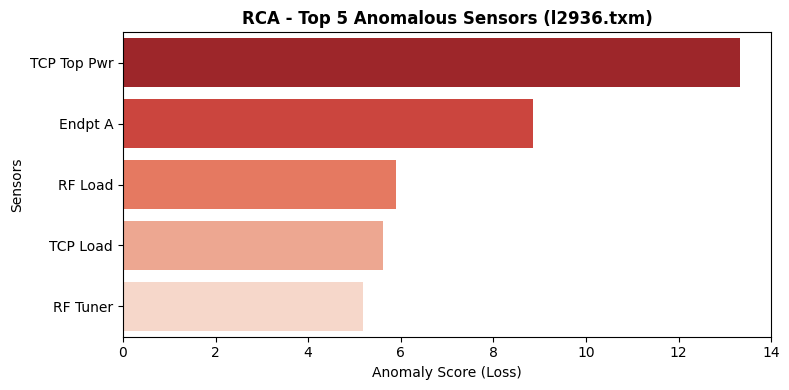

  1위. TCP Top Pwr: 13.3365
  2위. Endpt A: 8.8561
  3위. RF Load: 5.9075
  4위. TCP Load: 5.6116
  5위. RF Tuner: 5.1870

 🏭 Wafer Analysis Report: [ l2937.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


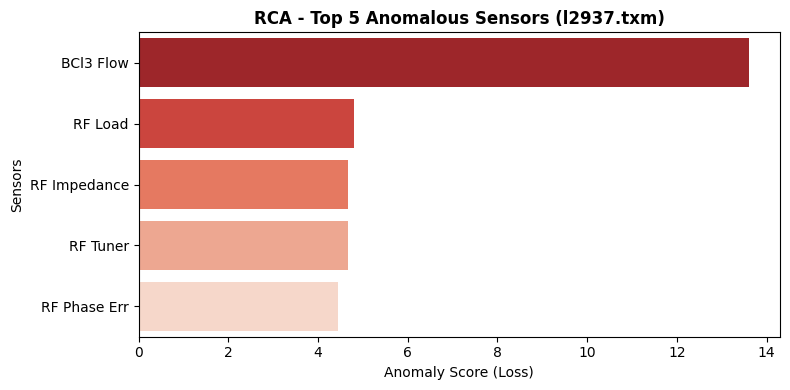

  1위. BCl3 Flow: 13.6178
  2위. RF Load: 4.8008
  3위. RF Impedance: 4.6714
  4위. RF Tuner: 4.6685
  5위. RF Phase Err: 4.4500

 🏭 Wafer Analysis Report: [ l2938.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


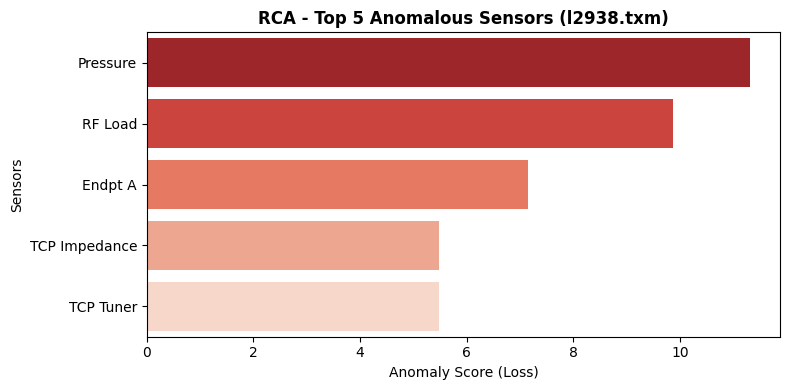

  1위. Pressure: 11.3079
  2위. RF Load: 9.8663
  3위. Endpt A: 7.1433
  4위. TCP Impedance: 5.4815
  5위. TCP Tuner: 5.4796

 🏭 Wafer Analysis Report: [ l2939.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


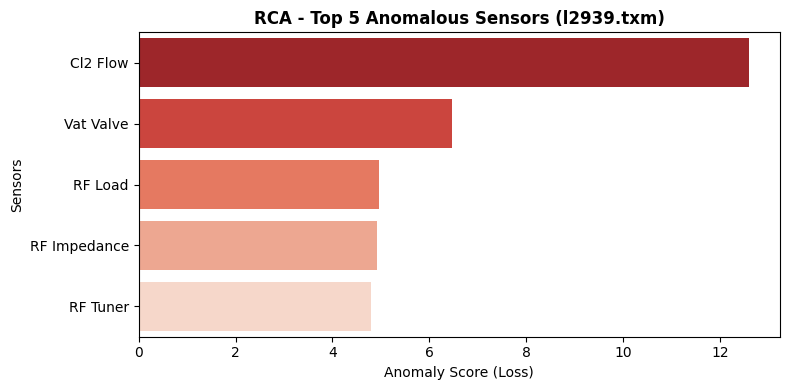

  1위. Cl2 Flow: 12.5989
  2위. Vat Valve: 6.4611
  3위. RF Load: 4.9528
  4위. RF Impedance: 4.9272
  5위. RF Tuner: 4.7891

 🏭 Wafer Analysis Report: [ l2940.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


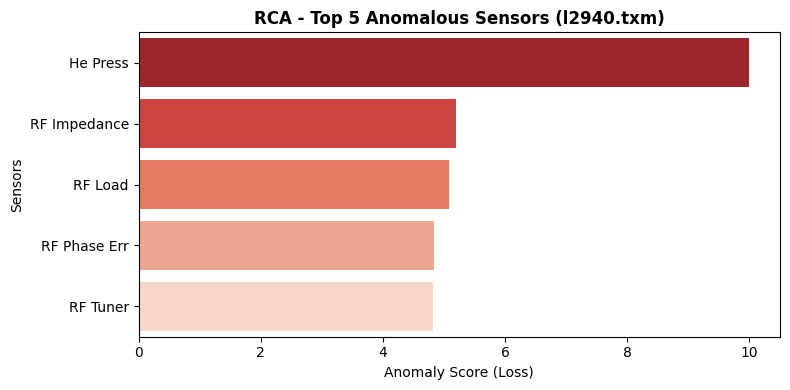

  1위. He Press: 10.0038
  2위. RF Impedance: 5.1991
  3위. RF Load: 5.0818
  4위. RF Phase Err: 4.8460
  5위. RF Tuner: 4.8261
  ✅ [21/23] l2941.txm : 정상 통과 (Score: 2.9307)
  ✅ [22/23] l2942.txm : 정상 통과 (Score: 2.9668)

 🏭 Wafer Analysis Report: [ l2943.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


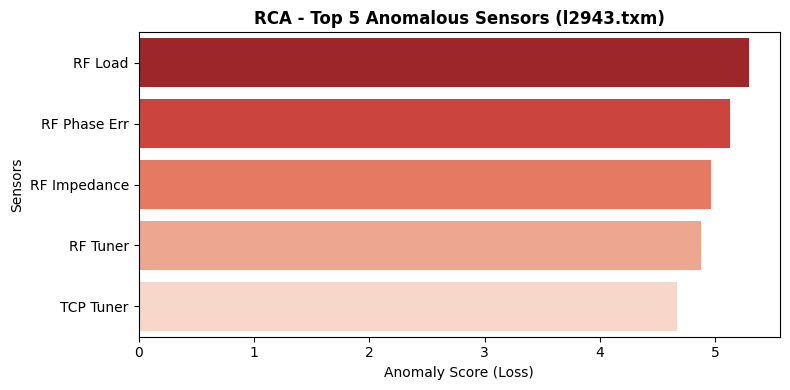

  1위. RF Load: 5.2943
  2위. RF Phase Err: 5.1249
  3위. RF Impedance: 4.9610
  4위. RF Tuner: 4.8782
  5위. TCP Tuner: 4.6672

💾 [l29] 전체 웨이퍼 변수별 Anomaly Score 통합 엑셀 저장 완료:
   경로: /content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved/TRACE_GPT_l29_All_Wafers_RCA.xlsx

  [l29] 실험군 테스트셋 분석 요약 보고서
 - 전체 분석 대상: 23개
 -  최종 정상(Normal) 판정: 13개
 -  최종 불량(Fault) 판정: 10개


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [l31] 실험군 전체 테스트셋 분석 시작
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ 모델 로드 성공! (Threshold: 3.3342)
▶ 타겟 데이터: 정상 15개 | 불량 6개 (총 분석 대상: 21개)


 🏭 Wafer Analysis Report: [ l3120.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


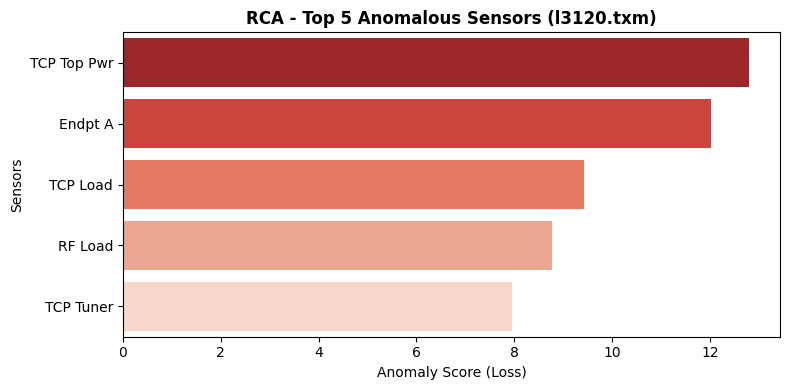

  1위. TCP Top Pwr: 12.7894
  2위. Endpt A: 12.0096
  3위. TCP Load: 9.4151
  4위. RF Load: 8.7721
  5위. TCP Tuner: 7.9442

 🏭 Wafer Analysis Report: [ l3121.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


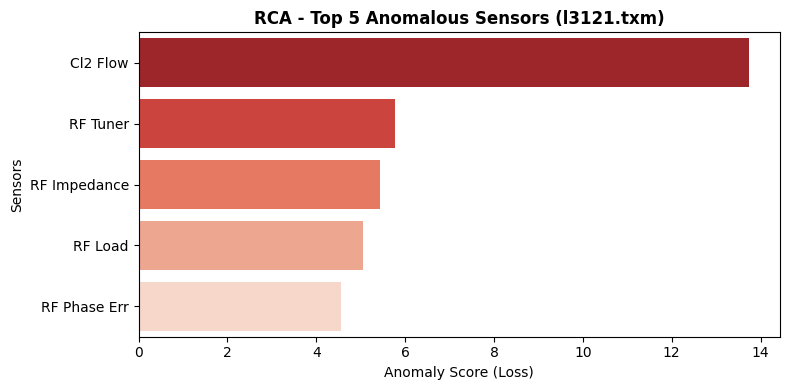

  1위. Cl2 Flow: 13.7494
  2위. RF Tuner: 5.7612
  3위. RF Impedance: 5.4246
  4위. RF Load: 5.0592
  5위. RF Phase Err: 4.5457

 🏭 Wafer Analysis Report: [ l3122.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


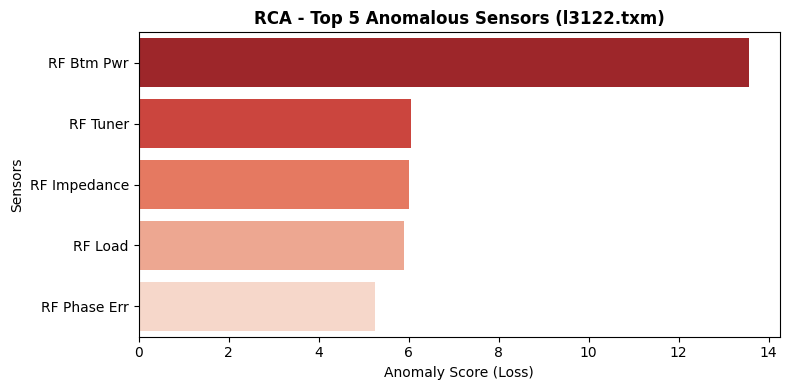

  1위. RF Btm Pwr: 13.5739
  2위. RF Tuner: 6.0560
  3위. RF Impedance: 6.0053
  4위. RF Load: 5.9016
  5위. RF Phase Err: 5.2492
  ✅ [4/21] l3126.txm : 정상 통과 (Score: 2.8480)
  ✅ [5/21] l3127.txm : 정상 통과 (Score: 3.1969)
  ✅ [6/21] l3128.txm : 정상 통과 (Score: 3.0973)
  ✅ [7/21] l3129.txm : 정상 통과 (Score: 2.9293)
  ✅ [8/21] l3130.txm : 정상 통과 (Score: 3.1405)
  ✅ [9/21] l3131.txm : 정상 통과 (Score: 3.0632)
  ✅ [10/21] l3132.txm : 정상 통과 (Score: 3.0581)
  ✅ [11/21] l3133.txm : 정상 통과 (Score: 3.0802)
  ✅ [12/21] l3134.txm : 정상 통과 (Score: 2.9599)
  ✅ [13/21] l3135.txm : 정상 통과 (Score: 3.0251)
  ✅ [14/21] l3136.txm : 정상 통과 (Score: 3.0052)
  ✅ [15/21] l3137.txm : 정상 통과 (Score: 3.0011)
  ✅ [16/21] l3138.txm : 정상 통과 (Score: 3.2541)
  ✅ [17/21] l3139.txm : 정상 통과 (Score: 3.1380)
  ✅ [18/21] l3140.txm : 정상 통과 (Score: 3.1909)

 🏭 Wafer Analysis Report: [ l3141.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


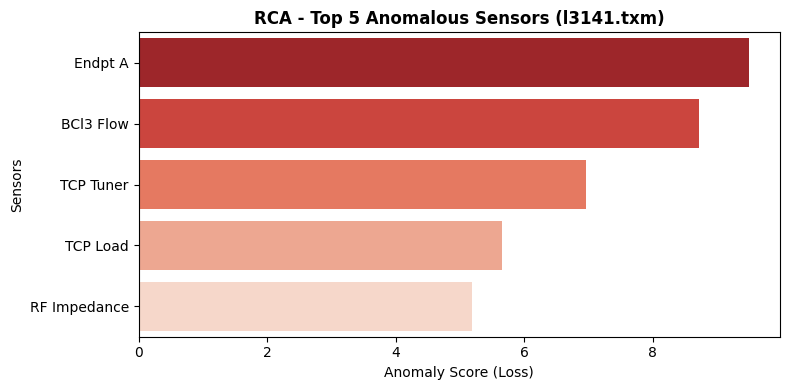

  1위. Endpt A: 9.5060
  2위. BCl3 Flow: 8.7139
  3위. TCP Tuner: 6.9551
  4위. TCP Load: 5.6614
  5위. RF Impedance: 5.1866

 🏭 Wafer Analysis Report: [ l3142.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


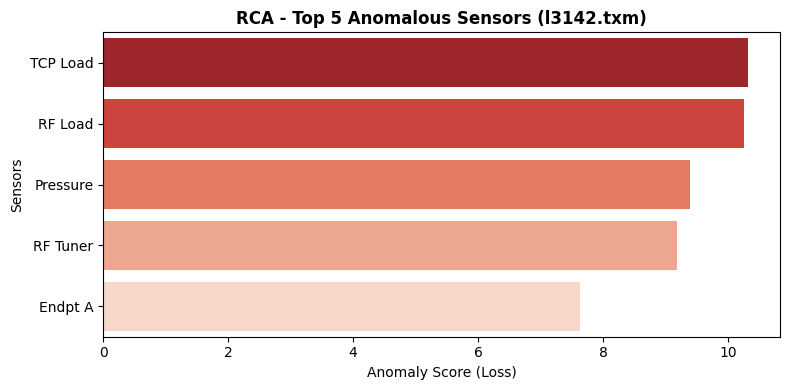

  1위. TCP Load: 10.3096
  2위. RF Load: 10.2523
  3위. Pressure: 9.3813
  4위. RF Tuner: 9.1770
  5위. Endpt A: 7.6308

 🏭 Wafer Analysis Report: [ l3143.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


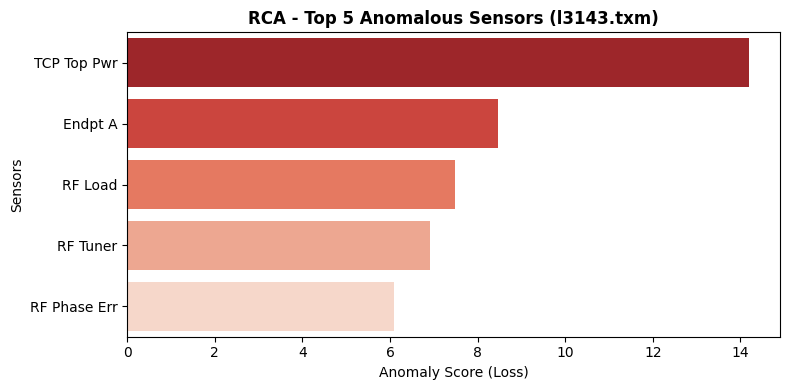

  1위. TCP Top Pwr: 14.1922
  2위. Endpt A: 8.4771
  3위. RF Load: 7.4740
  4위. RF Tuner: 6.9083
  5위. RF Phase Err: 6.0961

💾 [l31] 전체 웨이퍼 변수별 Anomaly Score 통합 엑셀 저장 완료:
   경로: /content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved/TRACE_GPT_l31_All_Wafers_RCA.xlsx

  [l31] 실험군 테스트셋 분석 요약 보고서
 - 전체 분석 대상: 21개
 -  최종 정상(Normal) 판정: 15개
 -  최종 불량(Fault) 판정: 6개


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [l33] 실험군 전체 테스트셋 분석 시작
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ 모델 로드 성공! (Threshold: 3.1569)
▶ 타겟 데이터: 정상 15개 | 불량 6개 (총 분석 대상: 21개)


 🏭 Wafer Analysis Report: [ l3318.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


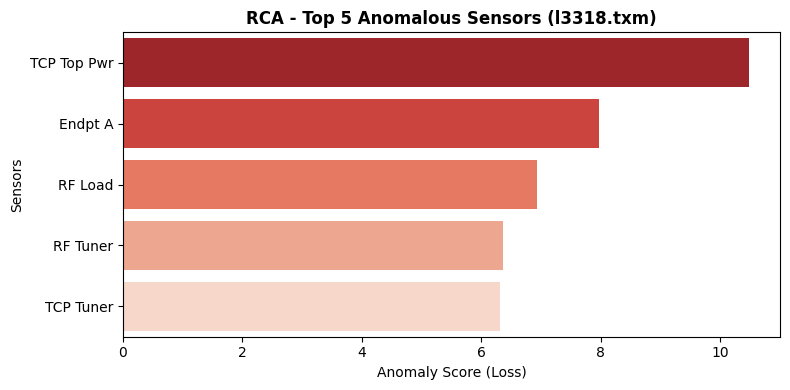

  1위. TCP Top Pwr: 10.4776
  2위. Endpt A: 7.9689
  3위. RF Load: 6.9400
  4위. RF Tuner: 6.3643
  5위. TCP Tuner: 6.3141

 🏭 Wafer Analysis Report: [ l3319.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


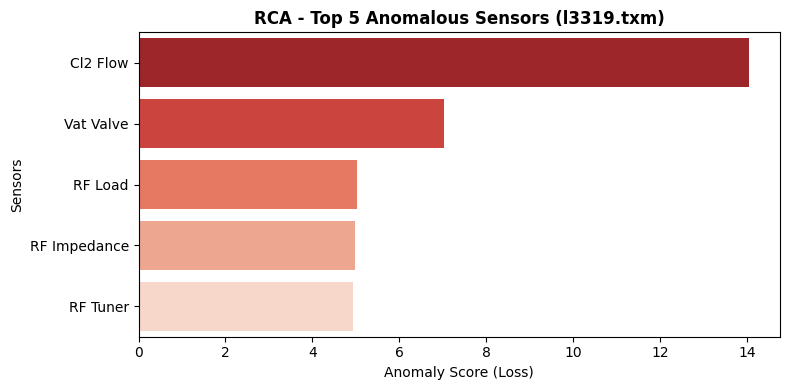

  1위. Cl2 Flow: 14.0588
  2위. Vat Valve: 7.0223
  3위. RF Load: 5.0305
  4위. RF Impedance: 4.9782
  5위. RF Tuner: 4.9320

 🏭 Wafer Analysis Report: [ l3320.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


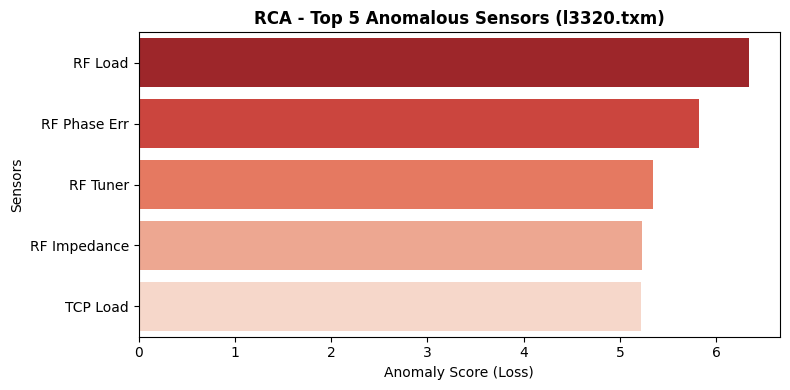

  1위. RF Load: 6.3430
  2위. RF Phase Err: 5.8198
  3위. RF Tuner: 5.3388
  4위. RF Impedance: 5.2319
  5위. TCP Load: 5.2187
  ✅ [4/21] l3326.txm : 정상 통과 (Score: 3.0268)
  ✅ [5/21] l3327.txm : 정상 통과 (Score: 2.6890)
  ✅ [6/21] l3328.txm : 정상 통과 (Score: 2.6943)
  ✅ [7/21] l3329.txm : 정상 통과 (Score: 2.7748)
  ✅ [8/21] l3330.txm : 정상 통과 (Score: 2.8860)
  ✅ [9/21] l3331.txm : 정상 통과 (Score: 2.6782)
  ✅ [10/21] l3332.txm : 정상 통과 (Score: 2.7638)
  ✅ [11/21] l3333.txm : 정상 통과 (Score: 2.6525)
  ✅ [12/21] l3334.txm : 정상 통과 (Score: 2.9372)
  ✅ [13/21] l3335.txm : 정상 통과 (Score: 2.8661)
  ✅ [14/21] l3336.txm : 정상 통과 (Score: 2.8468)
  ✅ [15/21] l3337.txm : 정상 통과 (Score: 2.6230)
  ✅ [16/21] l3338.txm : 정상 통과 (Score: 2.8122)

 🏭 Wafer Analysis Report: [ l3339.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


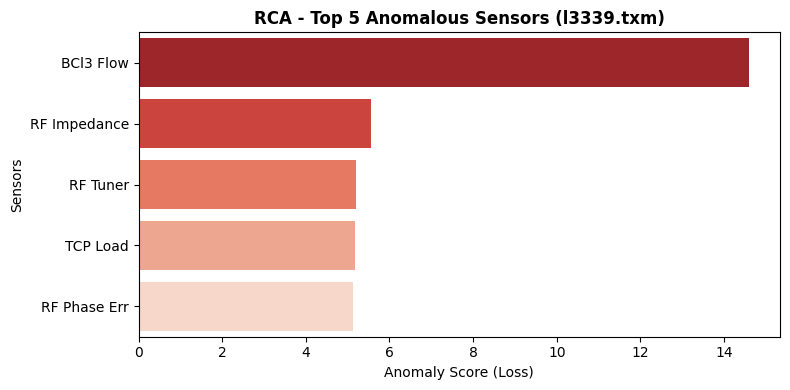

  1위. BCl3 Flow: 14.6062
  2위. RF Impedance: 5.5669
  3위. RF Tuner: 5.2048
  4위. TCP Load: 5.1805
  5위. RF Phase Err: 5.1346

 🏭 Wafer Analysis Report: [ l3340.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


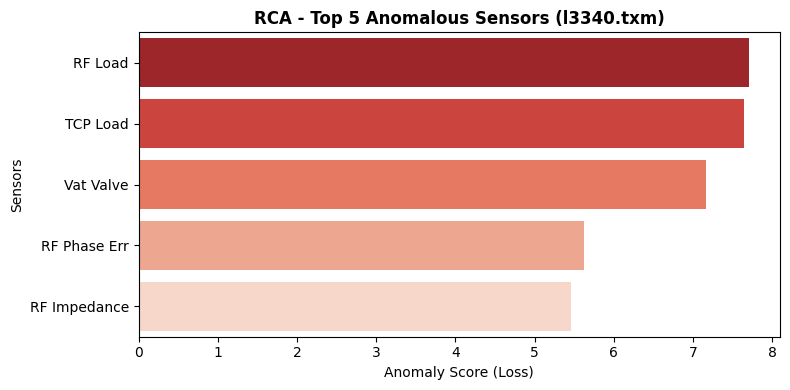

  1위. RF Load: 7.7141
  2위. TCP Load: 7.6416
  3위. Vat Valve: 7.1639
  4위. RF Phase Err: 5.6189
  5위. RF Impedance: 5.4570

 🏭 Wafer Analysis Report: [ l3341.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


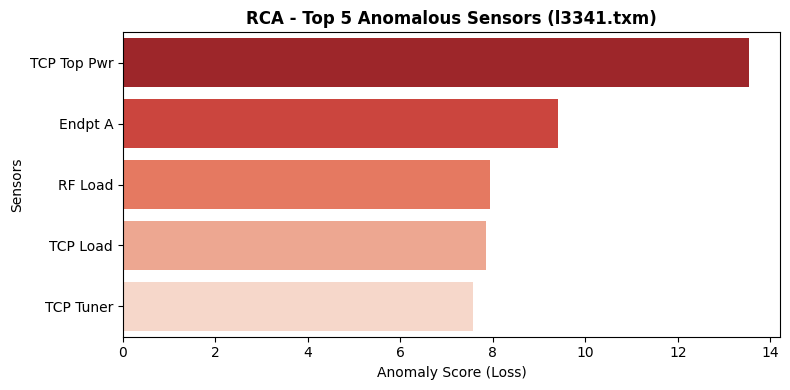

  1위. TCP Top Pwr: 13.5298
  2위. Endpt A: 9.3996
  3위. RF Load: 7.9400
  4위. TCP Load: 7.8511
  5위. TCP Tuner: 7.5753

 🏭 Wafer Analysis Report: [ l3342.txm ]
▶ 판정: 🚨 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis - Top 5 Sensors]


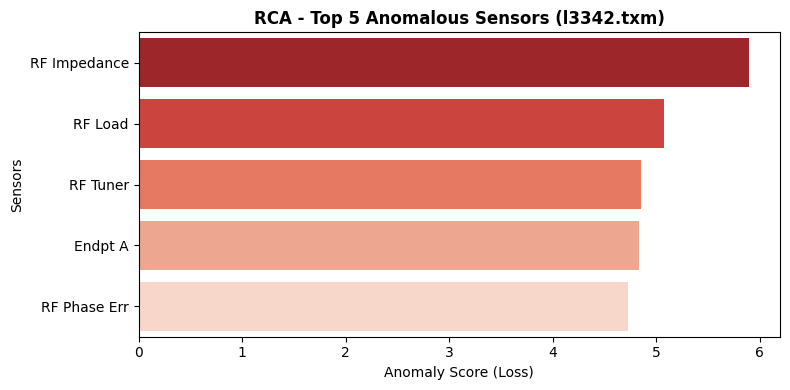

  1위. RF Impedance: 5.9006
  2위. RF Load: 5.0789
  3위. RF Tuner: 4.8526
  4위. Endpt A: 4.8364
  5위. RF Phase Err: 4.7306
  ✅ [21/21] l3343.txm : 정상 통과 (Score: 3.0365)

💾 [l33] 전체 웨이퍼 변수별 Anomaly Score 통합 엑셀 저장 완료:
   경로: /content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved/TRACE_GPT_l33_All_Wafers_RCA.xlsx

  [l33] 실험군 테스트셋 분석 요약 보고서
 - 전체 분석 대상: 21개
 -  최종 정상(Normal) 판정: 14개
 -  최종 불량(Fault) 판정: 7개



In [3]:
import os
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. 통합 분석 설정 및 원본 데이터 (1회 로드 최적화)
# =====================================================================
TARGET_EXP_IDS = ['l29', 'l31', 'l33']   #  순회할 실험군 리스트 지정
save_dir = "/content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved"
data_file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"

print(f" 거대 원본 데이터 로드 중 (1회만 수행됩니다): {data_file_path}")
raw_df = pd.read_excel(data_file_path) if data_file_path.endswith('.xlsx') else pd.read_csv(data_file_path)
print(" 원본 데이터 로드 완료!\n")

# =====================================================================
# 2. 각 실험군별 자동 순회 루프
# =====================================================================
for TARGET_EXP_ID in TARGET_EXP_IDS:
    print(f"\n" + "━"*80)
    print(f"  [{TARGET_EXP_ID}] 실험군 전체 테스트셋 분석 시작")
    print("━"*80)

    model_path = f"{save_dir}/trace_gpt_{TARGET_EXP_ID}.pth"
    meta_path = f"{save_dir}/metadata_{TARGET_EXP_ID}.pkl"

    if not os.path.exists(model_path) or not os.path.exists(meta_path):
        print(f"❌ [{TARGET_EXP_ID}] 저장된 모델이나 메타데이터가 없습니다. 건너뜁니다.")
        continue

    with open(meta_path, 'rb') as f:
        loaded_meta = pickle.load(f)

    config = loaded_meta['config']
    threshold = loaded_meta['threshold']
    sensor_cols = loaded_meta['sensor_cols']
    scaler = loaded_meta['scaler']
    SEQ_LEN = 32

    normal_wafers = np.unique(loaded_meta['ids_test_norm'])
    fault_wafers = np.unique(loaded_meta['ids_test_fault'])
    all_test_wafers = np.concatenate([normal_wafers, fault_wafers])
    unique_test_wafers = np.unique(all_test_wafers)
    total_count = len(unique_test_wafers)

    print(f"✅ 모델 로드 성공! (Threshold: {threshold:.4f})")
    print(f"▶ 타겟 데이터: 정상 {len(normal_wafers)}개 | 불량 {len(fault_wafers)}개 (총 분석 대상: {total_count}개)\n")

    loaded_model = TRACE_GPT(
        num_sensors=len(sensor_cols), seq_len=SEQ_LEN-1,
        d_model=config['d_model'], resolution=config['resolution']
    ).to(device)
    loaded_model.load_state_dict(torch.load(model_path, map_location=device))
    loaded_model.eval()

    # -----------------------------------------------------------------
    # (2) 웨이퍼 순회하며 개별 판별 및 RCA 통합 수집
    # -----------------------------------------------------------------
    normal_count = 0
    fault_count = 0
    not_found_count = 0

    # [추가] 모든 웨이퍼의 RCA(변수별 점수) 데이터를 담을 리스트
    all_rca_data = []

    for i, wafer_id in enumerate(unique_test_wafers, 1):
        target_df = raw_df[raw_df['Wafer_ID'] == wafer_id]

        if target_df.empty:
            print(f"  ❌ [{i}/{total_count}] 원본 데이터 누락: '{wafer_id}'")
            not_found_count += 1
            continue

        target_tensor = preprocess_and_window(target_df, sensor_cols, SEQ_LEN, scaler)

        if target_tensor is not None:
            target_tensor = target_tensor.to(device)

            # 오차 점수 산출
            window_scores = trace_calculate_window_scores(loaded_model, target_tensor, device, batch_size=32, resolution=config['resolution'])
            wafer_score = np.max(window_scores)

            # 합불 판정 논리 변수
            is_fault = wafer_score > threshold

            if is_fault:
                fault_count += 1
            else:
                normal_count += 1
                # 출력 창이 너무 지저분해지지 않도록 정상일 때는 한 줄만 간결하게 표시
                print(f"  ✅ [{i}/{total_count}] {wafer_id} : 정상 통과 (Score: {wafer_score:.4f})")

            # 정상/불량 상관없이 RCA 분석 실행 및 반환된 데이터(DataFrame) 리스트에 추가
            rca_df = analyze_single_wafer(
                model=loaded_model,
                wafer_tensor=target_tensor,
                wafer_id=wafer_id,
                threshold=threshold,
                sensor_cols=sensor_cols,
                device=device,
                resolution=config['resolution'],
                is_fault=is_fault # 불량 여부 전달
            )
            all_rca_data.append(rca_df)

    # -----------------------------------------------------------------
    # (3) 수집된 전체 데이터를 하나의 엑셀 파일로 병합 및 저장
    # -----------------------------------------------------------------
    if all_rca_data:
        final_rca_df = pd.concat(all_rca_data, ignore_index=True)
        rca_save_path = f"{save_dir}/TRACE_GPT_{TARGET_EXP_ID}_All_Wafers_RCA.xlsx"

        # 엑셀 저장
        final_rca_df.to_excel(rca_save_path, index=False)
        print(f"\n💾 [{TARGET_EXP_ID}] 전체 웨이퍼 변수별 Anomaly Score 통합 엑셀 저장 완료:")
        print(f"   경로: {rca_save_path}")

    # -----------------------------------------------------------------
    # (4) 해당 실험군 요약 보고서
    # -----------------------------------------------------------------
    print(f"\n" + "="*60)
    print(f"  [{TARGET_EXP_ID}] 실험군 테스트셋 분석 요약 보고서")
    print("="*60)
    print(f" - 전체 분석 대상: {total_count}개")
    print(f" -  최종 정상(Normal) 판정: {normal_count}개")
    print(f" -  최종 불량(Fault) 판정: {fault_count}개")
    if not_found_count > 0:
        print(f" - ❌ 데이터 누락(Skip): {not_found_count}개")
    print("="*60 + "\n")

In [4]:
import pickle
import numpy as np

TARGET_EXP_ID = 'l33'
save_dir = "/content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved"


model_path = f"{save_dir}/trace_gpt_{TARGET_EXP_ID}.pth"
meta_path = f"{save_dir}/metadata_{TARGET_EXP_ID}.pkl"

with open(meta_path, 'rb') as f:
    loaded_meta = pickle.load(f)

# 정상 웨이퍼 ID 목록 출력
normal_wafers = np.unique(loaded_meta['ids_test_norm'])
print(f"✅ [{TARGET_EXP_ID} 실험군] 테스트용 정상 웨이퍼 목록 (총 {len(normal_wafers)}개):")
print(normal_wafers)

print("-" * 50)

# 덤으로 불량 웨이퍼 ID 목록도 출력해보기
fault_wafers = np.unique(loaded_meta['ids_test_fault'])
print(f"🚨 [{TARGET_EXP_ID} 실험군] 테스트용 불량 웨이퍼 목록 (총 {len(fault_wafers)}개):")
print(fault_wafers)

✅ [l33 실험군] 테스트용 정상 웨이퍼 목록 (총 15개):
['l3326.txm' 'l3327.txm' 'l3328.txm' 'l3329.txm' 'l3330.txm' 'l3331.txm'
 'l3332.txm' 'l3333.txm' 'l3334.txm' 'l3335.txm' 'l3336.txm' 'l3337.txm'
 'l3338.txm' 'l3342.txm' 'l3343.txm']
--------------------------------------------------
🚨 [l33 실험군] 테스트용 불량 웨이퍼 목록 (총 6개):
['l3318.txm' 'l3319.txm' 'l3320.txm' 'l3339.txm' 'l3340.txm' 'l3341.txm']


In [5]:
TARGET_EXP_ID = 'l33'
TARGET_WAFER = 'l2915.txm'
save_dir = "/content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved"
data_file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx" # 원본 데이터 경로

model_path = f"{save_dir}/trace_gpt_{TARGET_EXP_ID}.pth"
meta_path = f"{save_dir}/metadata_{TARGET_EXP_ID}.pkl"

if not os.path.exists(model_path) or not os.path.exists(meta_path):
    print("❌ 저장된 모델/메타데이터가 없습니다.")
else:
    # 1. 메타데이터 (Threshold, Scaler 포함) 로드
    with open(meta_path, 'rb') as f:
        loaded_meta = pickle.load(f)

    config = loaded_meta['config']
    threshold = loaded_meta['threshold']
    sensor_cols = loaded_meta['sensor_cols']
    scaler = loaded_meta['scaler']
    SEQ_LEN = 32

    # 2. 모델 로드 및 가중치 주입
    loaded_model = TRACE_GPT(
        num_sensors=len(sensor_cols), seq_len=SEQ_LEN-1,
        d_model=config['d_model'], resolution=config['resolution']
    ).to(device)
    loaded_model.load_state_dict(torch.load(model_path, map_location=device))
    loaded_model.eval()

    # 3. 원본 데이터에서 타겟 웨이퍼 Raw Data 추출
    print(f"원본 데이터 로드 중: {data_file_path}")
    raw_df = pd.read_excel(data_file_path) if data_file_path.endswith('.xlsx') else pd.read_csv(data_file_path)
    target_df = raw_df[raw_df['Wafer_ID'] == TARGET_WAFER]

    if target_df.empty:
        print(f"❌ 원본 데이터에서 '{TARGET_WAFER}' 웨이퍼를 찾을 수 없습니다.")
    else:
        # 4. 실시간 전처리 (Scaling & Windowing)
        print("⚙️ 데이터 스케일링 및 슬라이딩 윈도우 변환 중...")
        target_tensor = preprocess_and_window(target_df, sensor_cols, SEQ_LEN, scaler)

        # 5. 분석 실행
        if target_tensor is not None:
            target_tensor = target_tensor.to(device)
            analyze_single_wafer(
                model=loaded_model,
                wafer_tensor=target_tensor,
                wafer_id=TARGET_WAFER,
                threshold=threshold,
                sensor_cols=sensor_cols,
                device=device,
                resolution=config['resolution']
            )

원본 데이터 로드 중: /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx
⚙️ 데이터 스케일링 및 슬라이딩 윈도우 변환 중...


In [6]:
# =====================================================================
# [추가 코드] 전체 테스트 웨이퍼 자동 순회 및 판별 (Batch Analysis)
# =====================================================================
print(f"\n" + "="*60)
print(f" 🚀 [{TARGET_EXP_ID}] 실험군의 전체 테스트셋 분석 시작")
print("="*60)

# 1. 메타데이터에서 테스트셋에 사용된 웨이퍼 ID 목록 추출
# (정상 웨이퍼와 불량 웨이퍼 ID를 모두 합칩니다)
all_test_wafers = np.concatenate([loaded_meta['ids_test_norm'], loaded_meta['ids_test_fault']])

# np.unique()를 사용하면 중복을 제거하고 정렬된 고유 ID 목록을 얻을 수 있습니다.
unique_test_wafers = np.unique(all_test_wafers)

print(f"총 분석 대상 웨이퍼 개수: {len(unique_test_wafers)}개\n")

# 2. 결과 통계를 저장할 변수 초기화
total_count = len(unique_test_wafers)
normal_count = 0
fault_count = 0
not_found_count = 0

# 3. 각 웨이퍼 ID별로 순회하며 분석 실행
for i, wafer_id in enumerate(unique_test_wafers, 1):
    print(f"\n[{i}/{total_count}] 웨이퍼 검사 중: {wafer_id}")

    # 원본 데이터에서 해당 웨이퍼 데이터 추출
    target_df = raw_df[raw_df['Wafer_ID'] == wafer_id]

    if target_df.empty:
        print(f"  ❌ 원본 데이터에서 '{wafer_id}'를 찾을 수 없습니다. 건너뜁니다.")
        not_found_count += 1
        continue

    # 전처리 (스케일링 및 슬라이딩 윈도우)
    target_tensor = preprocess_and_window(target_df, sensor_cols, SEQ_LEN, scaler)

    if target_tensor is not None:
        target_tensor = target_tensor.to(device)

        # 임계값과 비교하여 결과 판별을 위해 점수를 먼저 계산
        window_scores = trace_calculate_window_scores(loaded_model, target_tensor, device, batch_size=32, resolution=config['resolution'])
        wafer_score = np.max(window_scores)

        if wafer_score > threshold:
            fault_count += 1
            # 불량일 경우 analyze_single_wafer 함수를 호출하여 시각화 및 RCA 진행
            analyze_single_wafer(
                model=loaded_model,
                wafer_tensor=target_tensor,
                wafer_id=wafer_id,
                threshold=threshold,
                sensor_cols=sensor_cols,
                device=device,
                resolution=config['resolution']
            )
        else:
            normal_count += 1
            # 정상인 경우 간단한 메시지만 출력 (RCA 생략)
            print(f"  ▶ 판정: ✅ 정상 (Score: {wafer_score:.4f}, Threshold: {threshold:.4f})")

# 4. 최종 분석 요약 보고서 출력
print(f"\n" + "="*60)
print(f" 📊 [{TARGET_EXP_ID}] 실험군 테스트셋 분석 요약 보고서")
print("="*60)
print(f" - 전체 분석 대상: {total_count}개")
print(f" - ✅ 정상 (Normal) 판정: {normal_count}개")
print(f" - 🚨 불량 (Fault) 판정: {fault_count}개")
if not_found_count > 0:
    print(f" - ❌ 데이터 누락: {not_found_count}개")
print("="*60 + "\n")


 🚀 [l33] 실험군의 전체 테스트셋 분석 시작
총 분석 대상 웨이퍼 개수: 21개


[1/21] 웨이퍼 검사 중: l3318.txm

[2/21] 웨이퍼 검사 중: l3319.txm

[3/21] 웨이퍼 검사 중: l3320.txm

[4/21] 웨이퍼 검사 중: l3326.txm
  ▶ 판정: ✅ 정상 (Score: 3.0268, Threshold: 3.1569)

[5/21] 웨이퍼 검사 중: l3327.txm
  ▶ 판정: ✅ 정상 (Score: 2.6890, Threshold: 3.1569)

[6/21] 웨이퍼 검사 중: l3328.txm
  ▶ 판정: ✅ 정상 (Score: 2.6943, Threshold: 3.1569)

[7/21] 웨이퍼 검사 중: l3329.txm
  ▶ 판정: ✅ 정상 (Score: 2.7748, Threshold: 3.1569)

[8/21] 웨이퍼 검사 중: l3330.txm
  ▶ 판정: ✅ 정상 (Score: 2.8860, Threshold: 3.1569)

[9/21] 웨이퍼 검사 중: l3331.txm
  ▶ 판정: ✅ 정상 (Score: 2.6782, Threshold: 3.1569)

[10/21] 웨이퍼 검사 중: l3332.txm
  ▶ 판정: ✅ 정상 (Score: 2.7638, Threshold: 3.1569)

[11/21] 웨이퍼 검사 중: l3333.txm
  ▶ 판정: ✅ 정상 (Score: 2.6525, Threshold: 3.1569)

[12/21] 웨이퍼 검사 중: l3334.txm
  ▶ 판정: ✅ 정상 (Score: 2.9372, Threshold: 3.1569)

[13/21] 웨이퍼 검사 중: l3335.txm
  ▶ 판정: ✅ 정상 (Score: 2.8661, Threshold: 3.1569)

[14/21] 웨이퍼 검사 중: l3336.txm
  ▶ 판정: ✅ 정상 (Score: 2.8468, Threshold: 3.1569)

[15/21] 웨이퍼 검사 중: l3337.